## Question Group 1  
Use one of the following generative models—GAN, WGAN, or WGAN-GP—to learn and replicate the data distribution.  
[ref](https://chih-sheng-huang821.medium.com/pytorch%E6%89%8B%E6%8A%8A%E6%89%8B%E5%AF%A6%E4%BD%9C-generative-adversarial-network-8adae9a3092b)  
[ref 2](https://ithelp.ithome.com.tw/m/articles/10317845)

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad

# 設定參數
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
BATCH_SIZE = 128
LATENT_DIM = 2  # generative image dimension
EPOCHS = 100

cuda


生成兩群中心點分別為 (-3, -3) 跟 (7, 7) 的 cluster

In [2]:
def generate_cluster(radius_variance = 0.05, num_points = 1000):
  # fixed center point
  center_1 = [7, 7]
  center_2 = [-3, -3]

  # 共變異矩陣（圓形分布 → 單位矩陣乘以變異數）
  cov_matrix = [[radius_variance, 0], [0, radius_variance]]

  # 生成資料
  cluster_1 = np.random.multivariate_normal(center_1, cov_matrix, num_points)
  cluster_2 = np.random.multivariate_normal(center_2, cov_matrix, num_points)

  # 手動將中心點添加到 cluster 中
  cluster_1 = np.vstack([cluster_1, center_1])
  cluster_2 = np.vstack([cluster_2, center_2])

  return cluster_1, cluster_2

def show_cluster(cluster_1, cluster_2):
  # 畫圖
  plt.figure(figsize=(6,6))
  # draw all data
  plt.scatter(cluster_1[:, 0], cluster_1[:, 1], color='blue', label='Cluster 1', alpha=0.6)
  plt.scatter(cluster_2[:, 0], cluster_2[:, 1], color='red', label='Cluster 2', alpha=0.6)
  plt.legend()
  plt.grid(True)
  plt.axis('equal')  # 保持x、y等比例
  plt.title("Two Circular Clusters")
  plt.show()

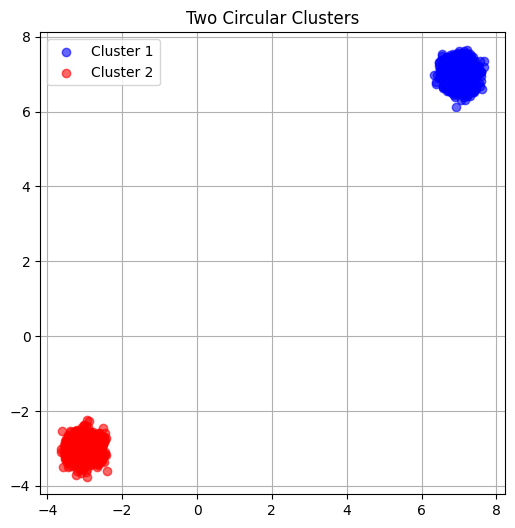

In [ ]:
if __name__ == "__main__":
  cluster_1, cluster_2 = generate_cluster()
  show_cluster(cluster_1, cluster_2)

### Define GAN

In [6]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.01),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.01),
            nn.Linear(64, latent_dim)
        )

    def forward(self, z):
        return self.model(z)

# 定義判別器
class Discriminator(nn.Module):
    def __init__(self, in_feaures):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_feaures, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
G = Generator(LATENT_DIM).to(device)
D = Discriminator(LATENT_DIM).to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer_G = optim.Adam(G.parameters(), lr=0.001)
optimizer_D = optim.Adam(D.parameters(), lr=0.001)

In [ ]:
np_data = np.vstack([cluster_1, cluster_2]) # 合併兩群資料
real_data = torch.tensor(np_data, dtype=torch.float32) # to tensor
dataloader = torch.utils.data.DataLoader(real_data, batch_size=BATCH_SIZE, shuffle=True)  # 轉成 pytorch dataloader

training

In [ ]:
from tqdm import tqdm

# store the loss for variation graph
d_loss_list = []
g_loss_list = []

for epoch in range(1, EPOCHS + 1):
  loop = tqdm(enumerate(dataloader), total=len(dataloader), desc=f"Epoch {epoch}")
  # store the total loss for discrimator and generator
  d_loss_total = 0
  g_loss_total = 0
  for i, real_samples in loop:
    real_samples = real_samples.to(device)

    # ====================
    # 1. 訓練 Discriminator (固定 Generator )
    # ====================
    z = torch.randn(real_samples.size(0), LATENT_DIM).to(device)  # (BATCH_SIZE, 2)
    fake_samples = G(z).detach()
    real_validity = D(real_samples)
    fake_validity = D(fake_samples)

    # calculate loss
    # 訓練嚴格的分辨器， 真資料輸出1，假資料輸出0
    real_loss = loss_fn(real_validity, torch.ones_like(real_validity))
    fake_loss = loss_fn(fake_validity, torch.zeros_like(fake_validity))
    d_loss = real_loss + fake_loss
    # accumlate
    d_loss_total += d_loss.item()

    # Backpropagate and optimize
    optimizer_D.zero_grad()
    d_loss.backward()
    optimizer_D.step()

    # ====================
    # 2. 訓練 Generator (固定 Discriminator )
    # ====================
    # 希望 G 產出的資料能讓 D 判斷錯（假資料被 D 認成真 → 輸出 1）
    z = torch.randn(real_samples.size(0), LATENT_DIM).to(device)
    gen_samples = G(z)
    g_loss = loss_fn(D(gen_samples), torch.ones_like(D(gen_samples)))
    # accumlate
    g_loss_total += g_loss.item()

    # Backpropagate and optimize
    optimizer_G.zero_grad()
    g_loss.backward()
    optimizer_G.step()

    # 更新 tqdm 顯示
    loop.set_postfix(d_loss=d_loss.item(), g_loss=g_loss.item())

  # store in list
  d_loss_list.append(d_loss_total / len(dataloader.dataset))
  g_loss_list.append(g_loss_total / len(dataloader.dataset))


Epoch 100: 100%|██████████| 16/16 [00:00<00:00, 96.29it/s, d_loss=1.03, g_loss=1.03] 


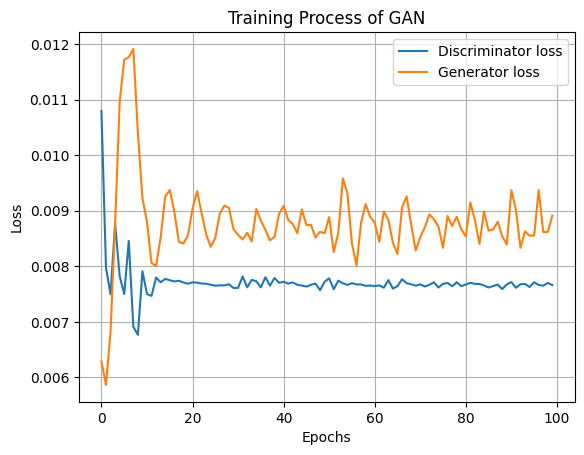

In [ ]:
#將圖片畫出來
plt.title('Training Process of GAN')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.plot(d_loss_list, label='Discriminator loss')
plt.plot(g_loss_list, label='Generator loss')
plt.legend(loc='best')
plt.grid(True)
plt.show()

i. Generate 50 data points using the trained model.

In [ ]:
G.eval()
with torch.no_grad():
    z = torch.randn(50, LATENT_DIM).to(device)
    gen_samples = G(z).cpu().numpy()

print(gen_samples)

[[-2.7777333 -2.6039963]
 [-2.8412192 -2.6601114]
 [-2.8019888 -2.6235328]
 [-2.8146088 -2.6371822]
 [-2.9648197 -2.7814808]
 [-2.9748132 -2.7808816]
 [-2.8843455 -2.6995378]
 [-2.786892  -2.6138043]
 [-2.8148437 -2.6362789]
 [-2.841952  -2.661315 ]
 [-2.8343644 -2.6535819]
 [-2.7993243 -2.624765 ]
 [-2.9630883 -2.7718892]
 [-2.8926404 -2.7109551]
 [-2.8348005 -2.6566486]
 [-2.7964206 -2.619573 ]
 [-2.9631004 -2.7692404]
 [-2.8607223 -2.6811812]
 [-2.7887921 -2.606966 ]
 [-2.9281545 -2.7409031]
 [-2.9123726 -2.727393 ]
 [-2.9334116 -2.7453697]
 [-2.9502296 -2.7730417]
 [-2.7957869 -2.6166372]
 [-2.8153517 -2.6512666]
 [-2.9376433 -2.7497942]
 [-2.831658  -2.655416 ]
 [-2.761497  -2.5840292]
 [-2.788813  -2.6072488]
 [-2.8646903 -2.6814325]
 [-2.9542983 -2.7729979]
 [-2.8719685 -2.6882858]
 [-2.9616203 -2.7677789]
 [-2.8846228 -2.7012465]
 [-2.9811447 -2.7884831]
 [-2.80806   -2.630019 ]
 [-2.905766  -2.722101 ]
 [-2.857379  -2.6822884]
 [-2.9093792 -2.7207258]
 [-2.8064518 -2.630909 ]


ii. Plot the generated points on a 2D graph to visualize how well they match the original distribution.

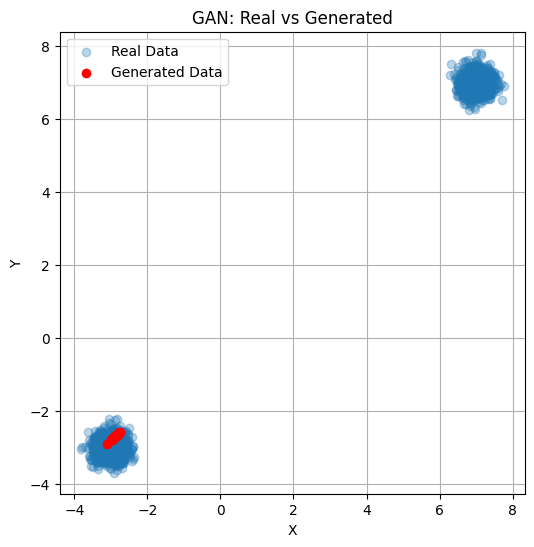

In [ ]:
real = np_data
plt.figure(figsize=(6,6))
plt.scatter(real[:,0], real[:,1], alpha=0.3, label='Real Data')
plt.scatter(gen_samples[:,0], gen_samples[:,1], c='red', label='Generated Data')
plt.legend()
plt.title("GAN: Real vs Generated")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

### Define WGAN
實作上改變 loss 計算  
[ref](https://blog.csdn.net/qq_37395293/article/details/103112721)  
[ref2](https://www.kaggle.com/code/rafat97/pytorch-wasserstein-gan-wgan)  

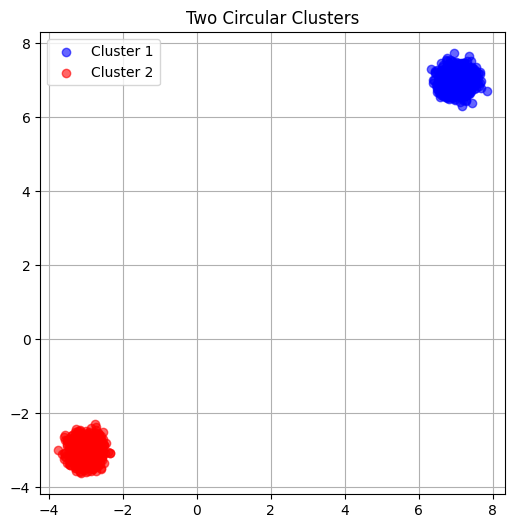

In [4]:
cluster_1, cluster_2 = generate_cluster()
show_cluster(cluster_1, cluster_2)

parameter from [this repo](https://github.com/eriklindernoren/PyTorch-GAN/blob/master/implementations/wgan_gp/wgan_gp.py)

In [122]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(16, 32),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(32, latent_dim),
        )

    def forward(self, z):
        return self.model(z)

# 定義判別器
class Discriminator(nn.Module):
    def __init__(self, in_feaures):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(in_feaures, 16),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(16, 32),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

In [150]:
G = Generator(LATENT_DIM).to(device)
D = Discriminator(LATENT_DIM).to(device)

# optimizers 改用 Adam
optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [8]:
np_data = np.vstack([cluster_1, cluster_2]) # 合併兩群資料
real_data = torch.tensor(np_data, dtype=torch.float32) # to tensor
dataloader = torch.utils.data.DataLoader(real_data, batch_size=BATCH_SIZE, shuffle=True)  # 轉成 pytorch dataloader

training

In [151]:
from tqdm import tqdm

# store the loss for variation graph
d_loss_list = []
g_loss_list = []
EPOCHS = 120

for epoch in range(1, EPOCHS + 1):
  loop = tqdm(enumerate(dataloader), total=len(dataloader), desc=f"Epoch {epoch}")
  # store the total loss for discrimator and generator
  d_loss_total = 0
  g_loss_total = 0
  for i, real_samples in loop:
    real_samples = real_samples.to(device)

    # ====================
    # 1. 訓練 Discriminator (固定 Generator )
    # ====================
    z = torch.randn(real_samples.size(0), LATENT_DIM).to(device)  # (BATCH_SIZE, 2)
    fake_samples = G(z).detach()
    real_validity = D(real_samples)
    fake_validity = D(fake_samples)

    # calculate loss
    # 訓練嚴格的分辨器， 真資料輸出1，假資料輸出0
    d_loss = -1 * torch.mean(real_validity) + torch.mean(fake_validity)
    # accumlate
    d_loss_total += d_loss.item()

    # Backpropagate and optimize
    optimizer_D.zero_grad()
    d_loss.backward()
    optimizer_D.step()

    ## clip weights
    for p in D.parameters():
        p.data.clamp_(-0.01, 0.01) # 或 -c, c，通常 c=0.01

    # train the generator for every n_critics iterations
    if i % 10 == 0:

    # ====================
    # 2. 訓練 Generator (固定 Discriminator )
    # ====================
    # 希望 G 產出的資料能讓 D 判斷錯（假資料被 D 認成真 → 輸出 1）
      accumlate_g_loss = 0
      # for i in range(2):
      z = torch.randn(real_samples.size(0), LATENT_DIM).to(device)
      gen_samples = G(z)
      g_loss = -1. * torch.mean(D(gen_samples))
      # accumlate
      g_loss_total += g_loss.item()
      accumlate_g_loss += g_loss.item()

      # Backpropagate and optimize
      optimizer_G.zero_grad()
      g_loss.backward()
      optimizer_G.step()

    # 更新 tqdm 顯示
    loop.set_postfix(d_loss=d_loss.item(), g_loss=accumlate_g_loss)

  # store in list
  d_loss_list.append(d_loss_total / len(dataloader.dataset))
  g_loss_list.append(g_loss_total / len(dataloader.dataset))


Epoch 120: 100%|██████████| 16/16 [00:00<00:00, 68.52it/s, d_loss=-0.00134, g_loss=0.00902]


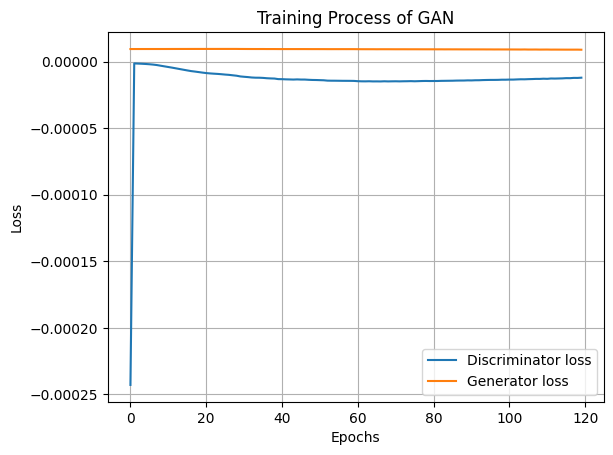

In [152]:
#將圖片畫出來
plt.title('Training Process of GAN')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.plot(d_loss_list, label='Discriminator loss')
plt.plot(g_loss_list, label='Generator loss')
plt.legend(loc='best')
plt.grid(True)
plt.show()

i. Generate 50 data points using the trained model.

In [153]:
G.eval()
with torch.no_grad():
    z = torch.randn(50, LATENT_DIM).to(device)
    gen_samples = G(z).cpu().numpy()

print(gen_samples)

[[ 1.766528    1.2657989 ]
 [ 1.5119821   1.2288439 ]
 [ 1.4422392   1.182666  ]
 [ 1.3660548   1.197045  ]
 [ 0.96800447  0.83414155]
 [ 1.4367741   1.032398  ]
 [ 1.7550122   1.2812046 ]
 [ 1.9643899   1.5761138 ]
 [ 1.4110439   1.2033261 ]
 [ 2.008783    1.6437145 ]
 [ 1.1971153   0.87345976]
 [ 2.4602084   2.0093555 ]
 [ 2.0370948   1.558972  ]
 [ 0.74989116  0.5866319 ]
 [ 1.5178862   1.1058304 ]
 [ 1.7679386   1.4386532 ]
 [ 1.0546554   0.76700646]
 [ 1.2747997   0.90804416]
 [ 2.9697056   2.2102015 ]
 [ 0.039256    0.25136358]
 [ 1.1690186   0.8392453 ]
 [ 1.938517    1.7477652 ]
 [ 2.4310396   1.8133025 ]
 [ 0.7944166   0.8145695 ]
 [ 1.867025    1.388887  ]
 [ 1.8467591   1.3045269 ]
 [ 1.5902079   1.254635  ]
 [ 1.2982464   1.0070379 ]
 [ 3.1188757   2.6868868 ]
 [ 2.93235     2.2468867 ]
 [ 1.237112    1.057939  ]
 [ 1.9064913   1.5526029 ]
 [ 1.7873517   1.2702065 ]
 [ 1.3572525   0.9909821 ]
 [ 1.1180543   0.8901458 ]
 [ 1.1114807   0.82217604]
 [-0.14776821  0.09209726]
 

ii. Plot the generated points on a 2D graph to visualize how well they match the original distribution.

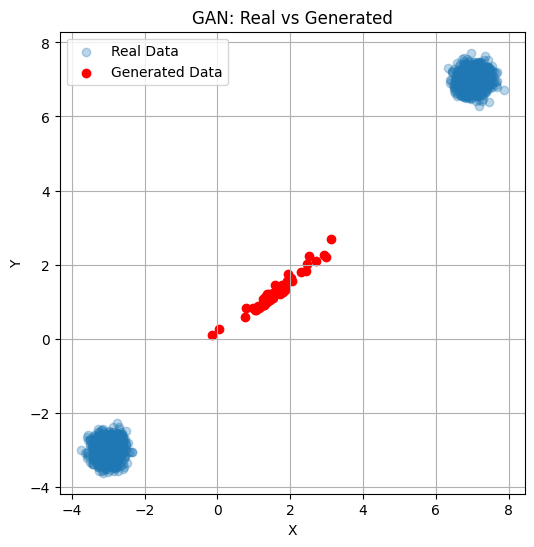

In [154]:
real = np_data
plt.figure(figsize=(6,6))
plt.scatter(real[:,0], real[:,1], alpha=0.3, label='Real Data')
plt.scatter(gen_samples[:,0], gen_samples[:,1], c='red', label='Generated Data')
plt.legend()
plt.title("GAN: Real vs Generated")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

### Define WGAN-GP  
[ref](https://www.kaggle.com/code/lmyybh/pytorch-wgan-gp)

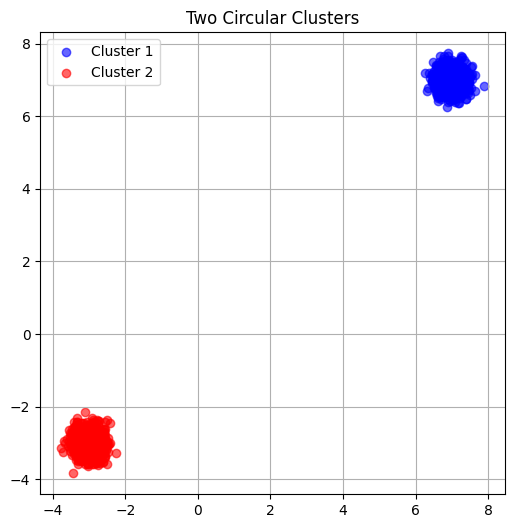

In [155]:
cluster_1, cluster_2 = generate_cluster()
show_cluster(cluster_1, cluster_2)

In [173]:
G = Generator(LATENT_DIM).to(device)
D = Discriminator(LATENT_DIM).to(device)

# optimizers 改用 Adam
optimizer_G = optim.Adam(G.parameters(), lr=0.0001, betas=(0.5, 0.9))
optimizer_D = optim.Adam(D.parameters(), lr=0.0001, betas=(0.5, 0.9))

In [161]:
np_data = np.vstack([cluster_1, cluster_2]) # 合併兩群資料
real_data = torch.tensor(np_data, dtype=torch.float32) # to tensor
dataloader = torch.utils.data.DataLoader(real_data, batch_size=BATCH_SIZE, shuffle=True)  # 轉成 pytorch dataloader

training

In [ ]:
def gradient_penalty(netD, real_data, fake_data, LAMDA=10, cuda=True):
    batch_size = real_data.size(0)  # 從資料本身取得真實 batch size
    alpha = torch.rand(batch_size, 1)   # broadcast when multiplication
    
    if cuda:
        alpha = alpha.cuda()
    x = (alpha * real_data + (1-alpha) * fake_data).requires_grad_(True)
    if cuda:
        x = x.cuda()
    out = netD(x)
    
    grad_outputs = torch.ones(out.shape)
    if cuda:
        grad_outputs = grad_outputs.cuda()
        
    gradients = torch.autograd.grad(outputs=out, inputs=x, grad_outputs=grad_outputs, create_graph=True, only_inputs=True)[0]
    gradients = gradients.reshape(batch_size, -1)
    
    return LAMDA * ((gradients.norm(2, dim=1)-1)**2).mean()

In [174]:
from tqdm import tqdm

# store the loss for variation graph
d_loss_list = []
g_loss_list = []
EPOCHS = 30

for epoch in range(1, EPOCHS + 1):
  loop = tqdm(enumerate(dataloader), total=len(dataloader), desc=f"Epoch {epoch}")
  # store the total loss for discrimator and generator
  d_loss_total = 0
  g_loss_total = 0
  for i, real_samples in loop:
    real_samples = real_samples.to(device)

    # ====================
    # 1. 訓練 Discriminator (固定 Generator )
    # ====================
    z = torch.randn(real_samples.size(0), LATENT_DIM).to(device)  # (BATCH_SIZE, 2)
    fake_samples = G(z).detach()
    real_validity = D(real_samples)
    fake_validity = D(fake_samples)
    # gradient penalty
    gp = gradient_penalty(D, real_samples, fake_samples, LAMDA=10)

    # calculate loss
    # 訓練嚴格的分辨器， 真資料輸出1，假資料輸出0
    d_loss = -1 * torch.mean(real_validity) + torch.mean(fake_validity) + gp
    # accumlate
    d_loss_total += d_loss.item()

    # Backpropagate and optimize
    optimizer_D.zero_grad()
    d_loss.backward()
    optimizer_D.step()

    # train the generator for every n_critics iterations
    if i % 5 == 0:

    # ====================
    # 2. 訓練 Generator (固定 Discriminator )
    # ====================
    # 希望 G 產出的資料能讓 D 判斷錯（假資料被 D 認成真 → 輸出 1）
      accumlate_g_loss = 0
      # for i in range(2):
      z = torch.randn(real_samples.size(0), LATENT_DIM).to(device)
      gen_samples = G(z)
      g_loss = -1. * torch.mean(D(gen_samples))
      # accumlate
      g_loss_total += g_loss.item()
      accumlate_g_loss += g_loss.item()

      # Backpropagate and optimize
      optimizer_G.zero_grad()
      g_loss.backward()
      optimizer_G.step()

    # 更新 tqdm 顯示
    loop.set_postfix(d_loss=d_loss.item(), g_loss=accumlate_g_loss)

  # store in list
  d_loss_list.append(d_loss_total / len(dataloader.dataset))
  g_loss_list.append(g_loss_total / len(dataloader.dataset))


Epoch 30: 100%|██████████| 16/16 [00:00<00:00, 50.94it/s, d_loss=-0.771, g_loss=-0.135]


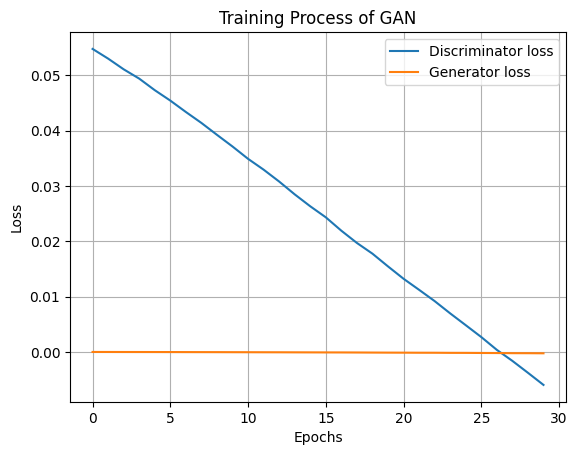

In [175]:
#將圖片畫出來
plt.title('Training Process of GAN')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.plot(d_loss_list, label='Discriminator loss')
plt.plot(g_loss_list, label='Generator loss')
plt.legend(loc='best')
plt.grid(True)
plt.show()

i. Generate 50 data points using the trained model.

In [176]:
G.eval()
with torch.no_grad():
    z = torch.randn(50, LATENT_DIM).to(device)
    gen_samples = G(z).cpu().numpy()

print(gen_samples)

[[ 0.22718695 -0.07200516]
 [ 0.15898138 -0.05259936]
 [ 0.3115703  -0.25227633]
 [ 0.39731514 -0.3180276 ]
 [ 0.3147108  -0.16830912]
 [ 0.25473467 -0.21231091]
 [ 0.24041519 -0.11612332]
 [ 0.15947609 -0.04776899]
 [ 0.32654613 -0.1202442 ]
 [ 0.34092665 -0.31620014]
 [ 0.05736558 -0.20667745]
 [ 0.33211145 -0.3681796 ]
 [ 0.3017033  -0.2904306 ]
 [ 0.28045365 -0.12393699]
 [ 0.15619756 -0.04528899]
 [ 0.15779    -0.05240358]
 [ 0.21422812 -0.100453  ]
 [ 0.31990552 -0.11316864]
 [ 0.35596716 -0.30344644]
 [ 0.16816884 -0.03896514]
 [ 0.39767992 -0.25095072]
 [ 0.09948267 -0.11898025]
 [ 0.18405318 -0.21816891]
 [ 0.26071924 -0.44616485]
 [ 0.11623552 -0.07105297]
 [ 0.36297634 -0.25457403]
 [ 0.24344885 -0.12048512]
 [ 0.30206412 -0.07514393]
 [ 0.4041963  -0.3839588 ]
 [ 0.229882   -0.25692856]
 [ 0.41455778 -0.23381406]
 [ 0.46165884 -0.31829023]
 [ 0.2487326  -0.09549893]
 [ 0.2370621  -0.09842085]
 [ 0.2772219  -0.09917935]
 [ 0.11655173 -0.05761843]
 [ 0.16260922 -0.05367621]
 

ii. Plot the generated points on a 2D graph to visualize how well they match the original distribution.

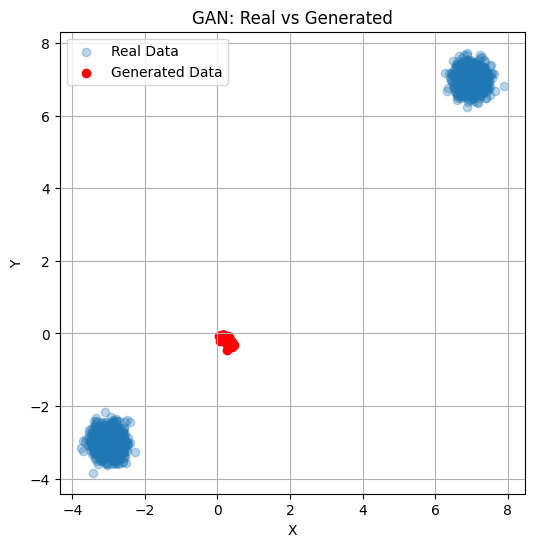

In [177]:
real = np_data
plt.figure(figsize=(6,6))
plt.scatter(real[:,0], real[:,1], alpha=0.3, label='Real Data')
plt.scatter(gen_samples[:,0], gen_samples[:,1], c='red', label='Generated Data')
plt.legend()
plt.title("GAN: Real vs Generated")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

## Question Group 2
InfoGAN

In [ ]:
from torch.utils.data import TensorDataset
def prepare_cluster_dataset(cluster_1, cluster_2):
    # 標籤 (cluster_1 → label [1, 0], cluster_2 → label [0, 1])
    labels_1 = np.tile([1, 0], (cluster_1.shape[0], 1))
    labels_2 = np.tile([0, 1], (cluster_2.shape[0], 1))

    # 合併資料與標籤
    data = np.vstack([cluster_1, cluster_2])           # shape: (N, 2)
    labels = np.concatenate([labels_1, labels_2])      # shape: (N, 2)

    # 轉成 torch tensor
    data_tensor = torch.tensor(data, dtype=torch.float32)
    label_tensor = torch.tensor(labels, dtype=torch.long)

    return TensorDataset(data_tensor, label_tensor)

if __name__ == "__main__":
  cluster_1, cluster_2 = generate_cluster(num_points = 5000)
  dataset_with_label = prepare_cluster_dataset(cluster_1, cluster_2)
  BATCH_SIZE = 512
  print('Batch Size =', BATCH_SIZE)
  dataloader = torch.utils.data.DataLoader(dataset_with_label, batch_size=BATCH_SIZE, shuffle=True)

  # test
  for i, (data, label) in enumerate(dataloader):
    print("data:", data[:5])
    print("label:", label[:5])
    break

Batch Size = 512
data: tensor([[-2.4413, -3.2218],
        [-3.0283, -2.7097],
        [-3.3054, -2.5600],
        [ 7.0032,  6.9860],
        [ 6.8811,  7.3643]])
label: tensor([[0, 1],
        [0, 1],
        [0, 1],
        [1, 0],
        [1, 0]])


In [ ]:
class INFO_Generator(nn.Module):
    def __init__(self, noise_dim=2, cat_dim=2):
        super().__init__()
        input_dim = noise_dim + cat_dim
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2)  # 輸出 2D 點
        )

    def forward(self, z, c):
        x = torch.cat([z, c], dim=1)
        return self.model(x)

class INFO_Discriminator(nn.Module):
    def __init__(self, input_dim=2, cat_dim=2):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        self.dis_output = nn.Linear(32, 1)         # 真偽判別
        self.q_output = nn.Linear(32, cat_dim)     # Q 預測分類機率

    def forward(self, x):
        feat = self.shared(x)
        validity = self.dis_output(feat)
        q_logits = self.q_output(feat)
        return validity, q_logits

In [ ]:
noise_dim = 2
cat_dim = 2
G = INFO_Generator(noise_dim, cat_dim).to(device)
D = INFO_Discriminator(2, cat_dim).to(device)

loss_bce = nn.BCEWithLogitsLoss()
loss_ce = nn.CrossEntropyLoss()

INFO_optimizer_G = optim.Adam(G.parameters(), lr=0.0005)
INFO_optimizer_D = optim.SGD(D.parameters(), lr=0.005)

In [ ]:
from tqdm import tqdm

EPOCHS = 30
MULTIPLE_CHAIN = 3
LAMBDA = 0.1

# store the loss for variation graph
d_loss_list = []
g_loss_list = []
q_loss_list = []
total_g_loss_list = []

for epoch in range(EPOCHS):
    # temp variable
    d_loss_total = 0
    g_loss_total = 0
    q_loss_total = 0
    total_g_loss_total = 0

    loop = tqdm(enumerate(dataloader), total=len(dataloader), desc=f"Epoch {epoch}")
    for idx, (real_data, labels) in loop:
        real_data, labels = real_data.to(device), labels.to(device)

        z = torch.randn(real_data.size(0), noise_dim).to(device)
        c = torch.randint(0, 2, (real_data.size(0),))
        c_onehot = torch.nn.functional.one_hot(c, num_classes=2).float()
        fake_data = G(z, c_onehot)

        # === Train Discriminator ===
        real_valid, _ = D(real_data)
        fake_valid, _ = D(fake_data.detach())

        d_loss_real = loss_bce(real_valid, torch.ones_like(real_valid))
        d_loss_fake = loss_bce(fake_valid, torch.zeros_like(fake_valid))
        d_loss = d_loss_real + d_loss_fake
        # accumlate
        d_loss_total += d_loss.item()

        INFO_optimizer_D.zero_grad()
        d_loss.backward()
        INFO_optimizer_D.step()

        # === Train Generator + Q ===
        Average_loss = 0.0
        for _ in range(MULTIPLE_CHAIN): # 多訓練幾次
          z = torch.randn(real_data.size(0), noise_dim).to(device)
          c = torch.randint(0, 2, (real_data.size(0),))
          c_onehot = torch.nn.functional.one_hot(c, num_classes=2).float()
          fake_data = G(z, c_onehot)

          fake_valid, q_logits = D(fake_data)
          g_loss = loss_bce(fake_valid, torch.ones_like(fake_valid))
          q_loss = loss_ce(q_logits, c)

          total_g_loss = g_loss + LAMBDA * q_loss
          Average_loss += total_g_loss

          # accumlate
          g_loss_total += g_loss.item()
          q_loss_total += q_loss.item()

          INFO_optimizer_G.zero_grad()
          total_g_loss.backward()
          INFO_optimizer_G.step()

        total_g_loss_total += Average_loss.item() / MULTIPLE_CHAIN
        # 更新 tqdm 顯示
        loop.set_postfix(d_loss=d_loss.item(), total_g_loss=total_g_loss.item())

    # updata list
    d_loss_list.append(d_loss_total / len(dataloader.dataset))
    g_loss_list.append(g_loss_total / len(dataloader.dataset))
    q_loss_list.append(q_loss_total / len(dataloader.dataset))
    total_g_loss_list.append(total_g_loss_total / len(dataloader.dataset))


Epoch 29: 100%|██████████| 20/20 [00:00<00:00, 47.30it/s, d_loss=1.38, total_g_loss=0.778]


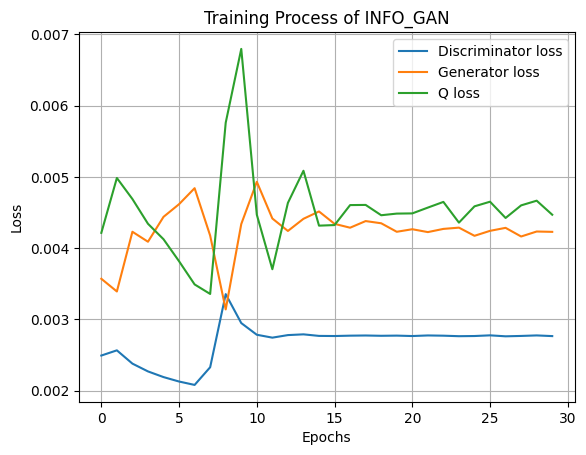

In [ ]:
#將圖片畫出來
plt.title('Training Process of INFO_GAN')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.plot(d_loss_list, label='Discriminator loss')
plt.plot(g_loss_list, label='Generator loss')
plt.plot(q_loss_list, label='Q loss')
# plt.plot(total_g_loss_list, label='Total Generator loss')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [ ]:
G.eval()
with torch.no_grad():
    z = torch.randn(50, LATENT_DIM).to(device)

    # 分別指定類別為 Cluster 1 和 Cluster 2
    c0 = torch.nn.functional.one_hot(torch.zeros(50, dtype=torch.long), 2).float().to(device)
    c1 = torch.nn.functional.one_hot(torch.ones(50, dtype=torch.long), 2).float().to(device)

    gen0 = G(z, c0).cpu().numpy()
    gen1 = G(z, c1).cpu().numpy()

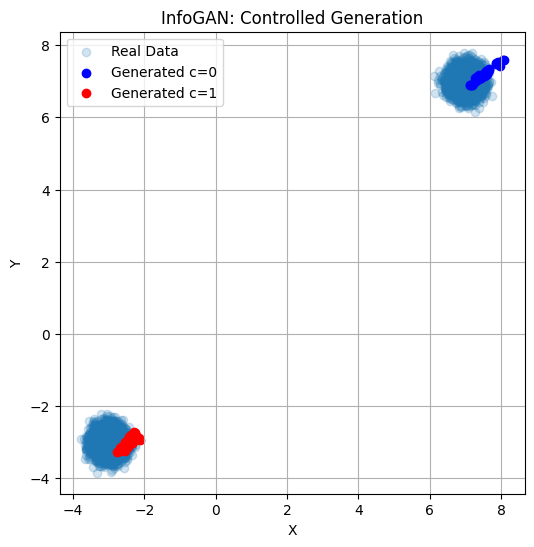

In [ ]:
plt.figure(figsize=(6,6))
real = np.vstack([cluster_1, cluster_2]) # 合併兩群資料
plt.scatter(real[:,0], real[:,1], alpha=0.2, label='Real Data')
plt.scatter(gen0[:,0], gen0[:,1], c='blue', label='Generated c=0')
plt.scatter(gen1[:,0], gen1[:,1], c='red', label='Generated c=1')
plt.legend()
plt.title("InfoGAN: Controlled Generation")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()